# 🌱 Using WheatFSPM with different climate scenarios and parameters

### Authors : R. Barillot, C.Chambon, M.Gauthier & B. Andrieu
### Publication : https://doi.org/10.1093/insilicoplants/diab034

This tutorial will illustrate how to use WheatFspm for different climate scenarios or parameter values. To that purpose, we will define a list of scenarios, then a generic function that will read the information of a given scenario and which will finally passed these variables to the model by calling a script *main.py*.

First, we will load a csv file defining the list of scenarios to be run. Each scenario has an id and a list of variables contained in the columns to be passed to WheatFspm.
NB: the last two columns illustrate how model parameters can be modified for a given scenario (for sensitivity analyses for instance).

In [17]:
import pandas as pd
import os


scenarios = pd.read_csv(os.path.join('inputs', 'scenarios_list.csv'))
scenarios.head()


,Scenario,Simulation_Length,Run_Simulation,Scenario_label,Plant_Density,Inter_Row,constant_Conc_Nitrates,METEO_FILENAME,growthwheat:VMAX_ROOTS_GROWTH_PREFLO,elongwheat:max_nb_leaves
0,1,48,True,N5U_PAR100_D1,1,1.00,35714.00000,meteo_PAR100.csv,0.01539,50
1,2,48,True,N50U_PAR100_D1,1,1.00,357143.00000,meteo_PAR100.csv,0.01539,50
2,3,48,True,N5U_PAR500_D500,500,0.15,35714.28571,meteo_PAR500.csv,0.01539,50
3,4,48,True,N50U_PAR500_D500,500,0.15,357142.85710,meteo_PAR500.csv,0.01539,50


Let's select a scenario

In [18]:
import ipywidgets as widgets
from IPython.display import display


scenario_options = (scenarios['Scenario'].astype(str) +
                        ' - ' +
                        scenarios['Scenario_label']).tolist()
selected_scenario_id = widgets.IntText(value=1)

# widget Dropdown
scenario_selector = widgets.Dropdown(
    options=scenario_options,
    value=scenario_options[0], # default scenario
    description='Scenario :',
    disabled=False,
)

def update_scenario(change):
    selected_id = int(change.new.split(' - ')[0])
    selected_scenario_id.value = selected_id

scenario_selector.observe(update_scenario, names='value')

print("Select a scenario :")
display(scenario_selector)


Select a scenario :


Dropdown(description='Scenario :', options=('1 - N5U_PAR100_D1', '2 - N50U_PAR100_D1', '3 - N5U_PAR500_D500', …

Then, we will define a function *run_wheatfspm* that will load the data from a specific scenario.

In [2]:
from example.Notebooks import tools
from example.Notebooks import main


def run_wheatfspm(scenario_id=1, inputs_dir_path='inputs', outputs_dir_path='outputs'):
    """
    Run the main.py of wheatfspm using data from a specific scenario

    :param int scenario_id: the index of the scenario to be read in the CSV file containing the list of scenarios
    :param str inputs_dir_path: the path directory of inputs
    :param str outputs_dir_path: the path to save outputs
    """

    # Path of the directory which contains the inputs of the model
    INPUTS_DIRPATH = inputs_dir_path

    # Scenario to be run
    scenarios_df = pd.read_csv(os.path.join(INPUTS_DIRPATH, 'scenarios_list.csv'), index_col='Scenario')
    scenario = scenarios_df.loc[scenario_id].to_dict()
    scenario_name = 'Scenario_%.4d' % scenario_id

    # -- SIMULATION PARAMETERS --

    # Create dict of parameters for the scenario. This includes the model parameters to be updated.
    scenario_parameters = tools.buildDic(scenario)

    # Length of the simulation (hours)
    SIMULATION_LENGTH = scenario_parameters.get('Simulation_Length', 48)

    # -- SIMULATION DIRECTORIES --

    # Path of the directory which contains the outputs of the model
    scenario_dirpath = os.path.join(outputs_dir_path, scenario_name)

    # Create the directory of the Scenario where results will be stored
    if not os.path.exists(scenario_dirpath):
        os.mkdir(scenario_dirpath)

    # Create directory paths for graphs, outputs and postprocessings of this scenario
    scenario_graphs_dirpath = os.path.join(scenario_dirpath, 'graphs')
    if not os.path.exists(scenario_graphs_dirpath):
        os.mkdir(scenario_graphs_dirpath)
    # Outputs
    scenario_outputs_dirpath = os.path.join(scenario_dirpath, 'outputs')
    if not os.path.exists(scenario_outputs_dirpath):
        os.mkdir(scenario_outputs_dirpath)
    # Postprocessings
    scenario_postprocessing_dirpath = os.path.join(scenario_dirpath, 'postprocessing')
    if not os.path.exists(scenario_postprocessing_dirpath):
        os.mkdir(scenario_postprocessing_dirpath)

    # -- SIMULATION CONDITIONS

    # Plant density and inter-row
    PLANT_DENSITY = {1: scenario_parameters.get('Plant_Density', 250.)}

    # Build N Fertilizations dict. In this example, constant nitrate concentrations are simulated in the soil (mimicking hydroponic)
    N_FERTILIZATIONS = {'constant_Conc_Nitrates': scenario_parameters.get('constant_Conc_Nitrates')}

    # # -- RUN main --
    main.main(simulation_length=SIMULATION_LENGTH,
              N_fertilizations=N_FERTILIZATIONS,
              PLANT_DENSITY=PLANT_DENSITY,
              METEO_FILENAME=scenario.get('METEO_FILENAME'),
              GRAPHS_DIRPATH=scenario_graphs_dirpath,
              OUTPUTS_DIRPATH=scenario_outputs_dirpath,
              POSTPROCESSING_DIRPATH=scenario_postprocessing_dirpath,
              update_parameters_all_models=scenario_parameters)

    return scenario_name


Finally, let's run a scenario from the list (wait for the end of simulation).

In [20]:
scenario_id = selected_scenario_id.value
scenario_name = run_wheatfspm(scenario_id)

t cnwheat is 0
t cnwheat is 1
t cnwheat is 2
t cnwheat is 3
t cnwheat is 4
t cnwheat is 5
t cnwheat is 6
t cnwheat is 7
t cnwheat is 8
t cnwheat is 9
t cnwheat is 10
t cnwheat is 11
t cnwheat is 12
t cnwheat is 13
t cnwheat is 14
t cnwheat is 15
t cnwheat is 16
t cnwheat is 17
t cnwheat is 18
t cnwheat is 19
t cnwheat is 20
t cnwheat is 21
t cnwheat is 22
t cnwheat is 23
t cnwheat is 24
t cnwheat is 25
t cnwheat is 26
t cnwheat is 27
t cnwheat is 28
t cnwheat is 29
t cnwheat is 30
t cnwheat is 31
t cnwheat is 32
t cnwheat is 33
t cnwheat is 34
t cnwheat is 35
t cnwheat is 36
t cnwheat is 37
t cnwheat is 38
t cnwheat is 39
t cnwheat is 40
t cnwheat is 41
t cnwheat is 42
t cnwheat is 43
t cnwheat is 44
t cnwheat is 45
t cnwheat is 46
t cnwheat is 47

Simulation run in 0:00:30
Creating postprocessing and graphs...
End of execution


Let's visualise some graphs

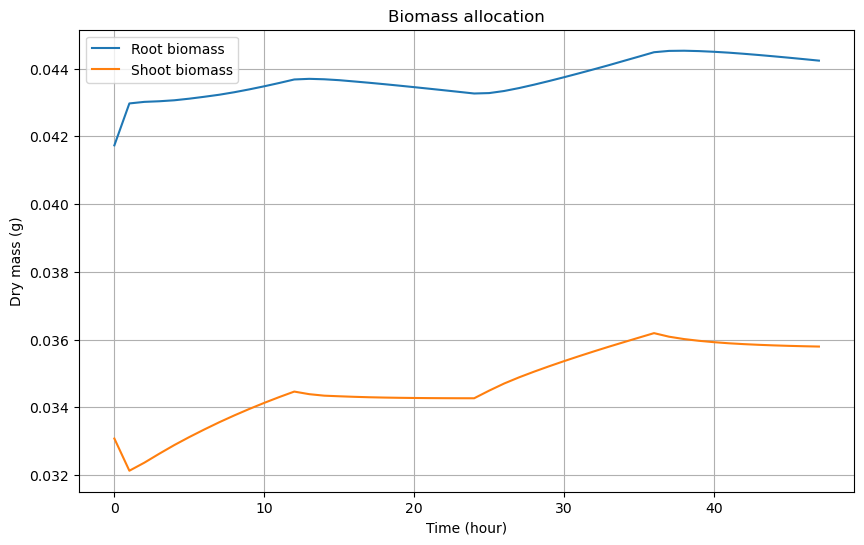

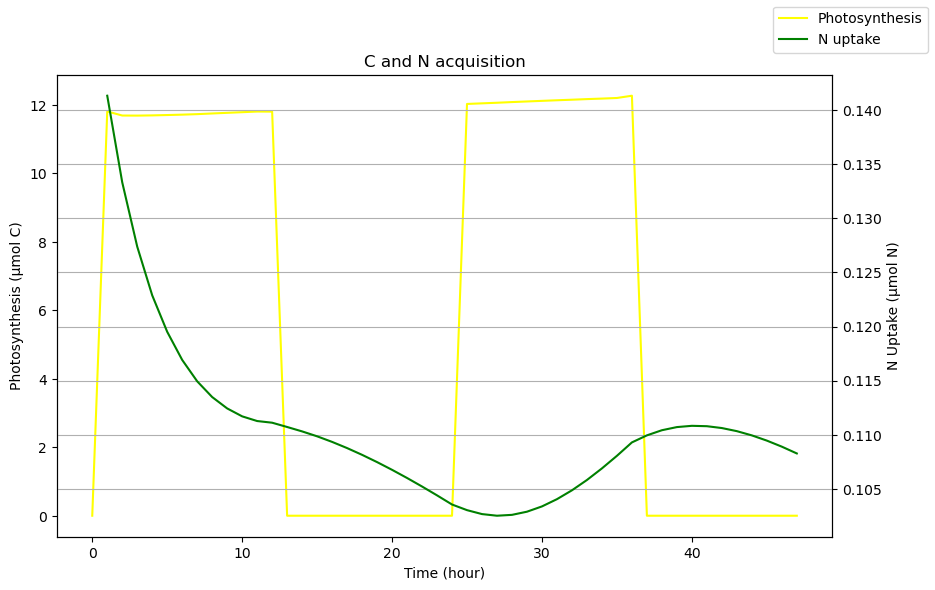

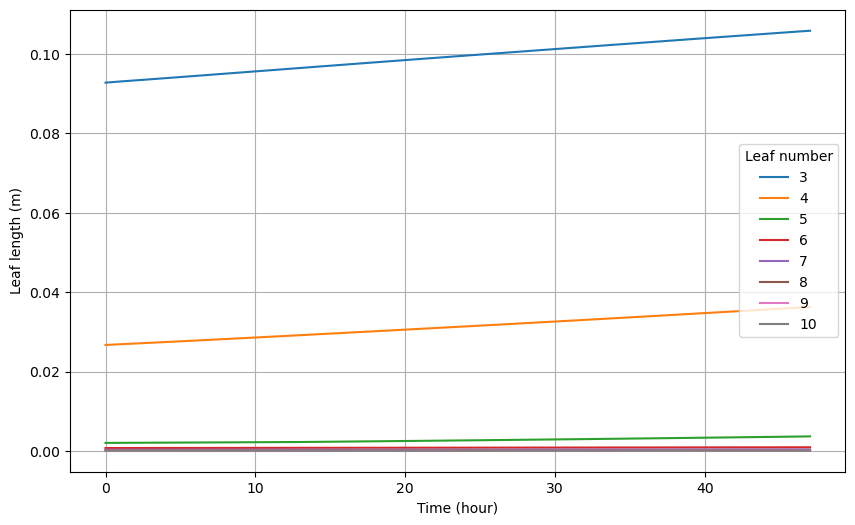

In [4]:
import matplotlib.pyplot as plt


axes_postprocessing_df = pd.read_csv(os.path.join('outputs', scenario_name, 'postprocessing', 'axes_postprocessing.csv'))
organs_postprocessing_df = pd.read_csv(os.path.join('outputs', scenario_name, 'postprocessing', 'organs_postprocessing.csv'))
roots_postprocessing_df = organs_postprocessing_df[organs_postprocessing_df['organ'] == 'roots']
hz_postprocessing_df = pd.read_csv(os.path.join('outputs', scenario_name, 'postprocessing', 'hiddenzones_postprocessing.csv'))

# Biomass allocation
plt.figure(figsize=(10, 6))
plt.plot(axes_postprocessing_df['t'], axes_postprocessing_df['sum_dry_mass_roots'], label='Root biomass')
plt.plot(axes_postprocessing_df['t'], axes_postprocessing_df['sum_dry_mass_shoot'], label='Shoot biomass')
plt.xlabel('Time (hour)')
plt.ylabel('Dry mass (g)')
plt.title('Biomass allocation')
plt.legend()
plt.grid(True)
plt.show()

# C and N acquisition
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(axes_postprocessing_df['t'], axes_postprocessing_df['Total_Photosynthesis'], label='Photosynthesis', color='yellow')
ax1.set_xlabel('Time (hour)')
ax1.set_ylabel('Photosynthesis (µmol C)')

ax2 = ax1.twinx()
ax2.plot(roots_postprocessing_df['t'], roots_postprocessing_df['Uptake_Nitrates'], label='N uptake', color='green')
ax2.set_ylabel('N Uptake (µmol N)')

plt.title('C and N acquisition')
fig.legend(loc='upper right')
plt.grid(True)
plt.show()

# Leaf length
plt.figure(figsize=(10, 6))
for metamer in hz_postprocessing_df['metamer'].unique():
    leaf = hz_postprocessing_df[hz_postprocessing_df['metamer'] == metamer]
    plt.plot(leaf['t'], leaf['leaf_L'], label=metamer)

plt.xlabel('Time (hour)')
plt.ylabel('Leaf length (m)')
plt.legend(loc='center right', title='Leaf number')
plt.grid(True)
plt.show()
